# CASIA-WEBFACE | Face Verification

#### Christian Budhi S

In [1]:
!git clone https://github.com/mk-minchul/AdaFace.git
!pip install -q torch torchvision scikit-learn pandas matplotlib

import sys
sys.path.insert(0, 'AdaFace')

Cloning into 'AdaFace'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 236 (delta 66), reused 56 (delta 56), pack-reused 129 (from 1)
Receiving objects: 100% (236/236), 38.95 MiB | 41.76 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [2]:
import pickle, io, os, struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    f1_score, accuracy_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

REC_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.rec'
IDX_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.idx'
EVAL_BINS = {
    'lfw'      : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/lfw.bin',
    'cfp_fp'   : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/cfp_fp.bin',
    'agedb_30' : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/agedb_30.bin',
    'sllfw'    : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/sllfw.bin',
    'talfw'    : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/talfw.bin',
}
OUT_DIR         = 'adaface_results'
VALID_MIN_BYTES = 100
CAL_SAMPLE_SIZE = 5000
_IR_FORMAT      = 'IfQQ'
_IR_SIZE        = struct.calcsize(_IR_FORMAT)
_IR_BUFFER      = 8

# AdaFace pretrained models to compare
# download from gdrive links in the README and place in AdaFace/pretrained/
ADAFACE_MODELS = {
    'adaface_r18_casia' : ('AdaFace/pretrained/adaface_ir18_casia.ckpt',  'ir_18'),
    'adaface_r50_ms1mv2': ('AdaFace/pretrained/adaface_ir50_ms1mv2.ckpt', 'ir_50'),
}

os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
import os
import gdown

os.makedirs('AdaFace/pretrained', exist_ok=True)

# Google Drive file IDs from AdaFace README
WEIGHTS = {
    'adaface_ir18_casia.ckpt'  : '1BURBDplf2bXpmwOL1WVzqtaVmQl9NpPe',  # R18, CASIA-WebFace
    'adaface_ir50_ms1mv2.ckpt' : '1eUaSHG4pGlIZK7hBkqjyp2fc2epKoBvI',  # R50, MS1MV2
}

for filename, file_id in WEIGHTS.items():
    out_path = f'AdaFace/pretrained/{filename}'
    if os.path.exists(out_path):
        print(f'[SKIP] {filename} already exists')
        continue
    print(f'[DOWNLOAD] {filename}...')
    gdown.download(
        f'https://drive.google.com/uc?id={file_id}',
        out_path,
        quiet=False,
        fuzzy=True
    )
    print(f'[DONE] {filename}  ({os.path.getsize(out_path)/1e6:.1f} MB)')

[DOWNLOAD] adaface_ir18_casia.ckpt...


Downloading...
From (original): https://drive.google.com/uc?id=1BURBDplf2bXpmwOL1WVzqtaVmQl9NpPe
From (redirected): https://drive.google.com/uc?id=1BURBDplf2bXpmwOL1WVzqtaVmQl9NpPe&confirm=t&uuid=d443e8c3-a99b-4f57-bd0b-94a947d2fe2f
To: /kaggle/working/AdaFace/pretrained/adaface_ir18_casia.ckpt
100%|██████████| 118M/118M [00:01<00:00, 91.6MB/s] 


[DONE] adaface_ir18_casia.ckpt  (117.9 MB)
[DOWNLOAD] adaface_ir50_ms1mv2.ckpt...


Downloading...
From (original): https://drive.google.com/uc?id=1eUaSHG4pGlIZK7hBkqjyp2fc2epKoBvI
From (redirected): https://drive.google.com/uc?id=1eUaSHG4pGlIZK7hBkqjyp2fc2epKoBvI&confirm=t&uuid=53d12a88-df37-491d-91c2-ab0389d9a56b
To: /kaggle/working/AdaFace/pretrained/adaface_ir50_ms1mv2.ckpt
100%|██████████| 700M/700M [00:08<00:00, 81.5MB/s] 

[DONE] adaface_ir50_ms1mv2.ckpt  (700.3 MB)


In [4]:
import struct
import numpy as np
from collections import Counter


idx = {}
with open(IDX_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        idx[int(key)] = int(offset)

labels = []
with open(REC_PATH, 'rb') as f:
    for offset in idx.values():
        f.seek(offset)
        f.read(_IR_BUFFER)
        label = struct.unpack(_IR_FORMAT, f.read(_IR_SIZE))[1]
        labels.append(int(label))

counts      = Counter(labels)
sorted_counts = sorted(counts.values(), reverse=True)

low_thresh  = int(np.percentile(sorted_counts, 10))
high_thresh = int(np.percentile(sorted_counts, 80))

high_x = next(i for i, c in enumerate(sorted_counts) if c <= high_thresh)
low_x  = next(i for i, c in enumerate(sorted_counts) if c <= low_thresh)

train_ids = {pid for pid, cnt in counts.items() if low_thresh <= cnt <= high_thresh}
test_ids = {pid for pid, cnt in counts.items() if cnt <= low_thresh or cnt >= high_thresh}

print(f"Keep identities with photos between {high_thresh} and {low_thresh}")
print(f"Identities kept  : {sum(low_thresh <= c <= high_thresh for c in counts.values()):,}  [{sum(c if low_thresh <= c <= high_thresh else 0 for c in counts.values())}]")
print(f"Identities total : {len(counts):,} [{sum(c for c in counts.values())}]")

Keep identities with photos between 57 and 15
Identities kept  : 7,824  [214927]
Identities total : 10,572 [501196]


In [13]:
import net   # from AdaFace repo

def load_adaface(ckpt_path, arch):
    model     = net.build_model(arch)
    statedict = torch.load(ckpt_path, map_location='cpu', weights_only=False)['state_dict']

    statedict = {k.replace('model.', ''): v for k, v in statedict.items()}
    statedict = {k: v for k, v in statedict.items() if not k.startswith('head.')}

    model.load_state_dict(statedict)
    model.eval()
    return model


def pil_to_adaface_input(img_pil, device):
    """
    Convert PIL RGB image to AdaFace input tensor.
    AdaFace expects: BGR, 112x112, normalized mean=0.5 std=0.5
    """
    img = img_pil.resize((112, 112))
    img = np.array(img)[:, :, ::-1]          # RGB → BGR
    img = (img / 255.0 - 0.5) / 0.5          # normalize
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # HWC → CHW
    return img.unsqueeze(0).to(device)        # add batch dim


@torch.no_grad()
def get_embedding(model, img_pil, device):
    """Get L2-normalized embedding from PIL Image."""
    inp           = pil_to_adaface_input(img_pil, device)
    feature, norm = model(inp)
    return F.normalize(feature, p=2, dim=1).squeeze().cpu().numpy()

In [14]:
import random
from collections import defaultdict

raw_idx = {}
with open(IDX_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        raw_idx[int(key)] = int(offset)

label_to_offsets = defaultdict(list)
with open(REC_PATH, 'rb') as f:
    for offset in raw_idx.values():
        f.seek(offset)
        magic, length = struct.unpack('II', f.read(_IR_BUFFER))
        flag, label, _, _ = struct.unpack(_IR_FORMAT, f.read(_IR_SIZE))
        img_size = length - _IR_SIZE
        if img_size < VALID_MIN_BYTES:
            continue
        pid = int(label)
        if pid in train_ids:
            label_to_offsets[pid].append(offset)

all_pids = [pid for pid, offs in label_to_offsets.items() if len(offs) >= 2]
print(f"Valid identities for calibration : {len(all_pids):,}")

def read_img_from_offset(rec_file, offset):
    rec_file.seek(offset)
    magic, length = struct.unpack('II', rec_file.read(_IR_BUFFER))
    rec_file.read(_IR_SIZE)
    img_size  = length - _IR_SIZE
    if img_size < VALID_MIN_BYTES:
        return None
    img_bytes = rec_file.read(img_size)
    try:
        return Image.open(io.BytesIO(img_bytes)).convert('RGB')
    except Exception:
        return None

def generate_calibration_pairs(n_pairs=CAL_SAMPLE_SIZE, seed=42):
    rng   = random.Random(seed)
    pairs = []
    for i in range(n_pairs):
        same  = rng.random() > 0.5
        pid_a = rng.choice(all_pids)
        off_a = rng.choice(label_to_offsets[pid_a])
        if same and len(label_to_offsets[pid_a]) >= 2:
            off_b = rng.choice([o for o in label_to_offsets[pid_a] if o != off_a])
            lbl   = 1
        else:
            pid_b = rng.choice([p for p in all_pids if p != pid_a])
            off_b = rng.choice(label_to_offsets[pid_b])
            lbl   = 0
        pairs.append((off_a, off_b, lbl))
    same_n = sum(1 for _, _, l in pairs if l == 1)
    print(f"Calibration pairs: {len(pairs):,}  (same={same_n:,}  diff={len(pairs)-same_n:,})")
    return pairs

cal_pairs = generate_calibration_pairs()

Valid identities for calibration : 7,824
Calibration pairs: 5,000  (same=2,501  diff=2,499)


In [15]:
def find_optimal_threshold(probs, labels):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    return float(thresholds[np.argmax(tpr - fpr)])

def compute_metrics(probs, labels, threshold):
    probs  = np.array(probs).flatten()
    labels = np.array(labels).flatten()
    preds  = (probs >= threshold).astype(int)
    return {
        'threshold': threshold,
        'auc'      : roc_auc_score(labels, probs),
        'ap'       : average_precision_score(labels, probs),
        'f1'       : f1_score(labels, preds, average='macro'),
        'acc'      : accuracy_score(labels, preds),
    }

def save_plots(probs, labels, preds, name, model_name, out_dir):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    RocCurveDisplay.from_predictions(labels, probs, ax=axes[0], name=name)
    axes[0].set_title(f'{name} — ROC')
    PrecisionRecallDisplay.from_predictions(labels, probs, ax=axes[1], name=name)
    axes[1].set_title(f'{name} — PR')
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['diff', 'same'], ax=axes[2]
    )
    axes[2].set_title(f'{name} — confusion matrix')
    plt.suptitle(f'{model_name} / {name}', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'{model_name}_{name}.png'), bbox_inches='tight')
    plt.show()
    plt.close(fig)


═══════════════════════════════════════════════════════
  adaface_r18_casia  (ir_18)
═══════════════════════════════════════════════════════

[1/2] Calibrating on 5000 train pairs...
  Pairs used    : 5,000  (skipped 0)
  Cal AUC       : 0.9745
  Cal threshold : 0.1615

[2/2] Evaluating benchmarks (threshold=0.1615)...

  ── lfw
    AUC : 0.9990
    AP  : 0.9992
    F1  : 0.9793
    ACC : 0.9793


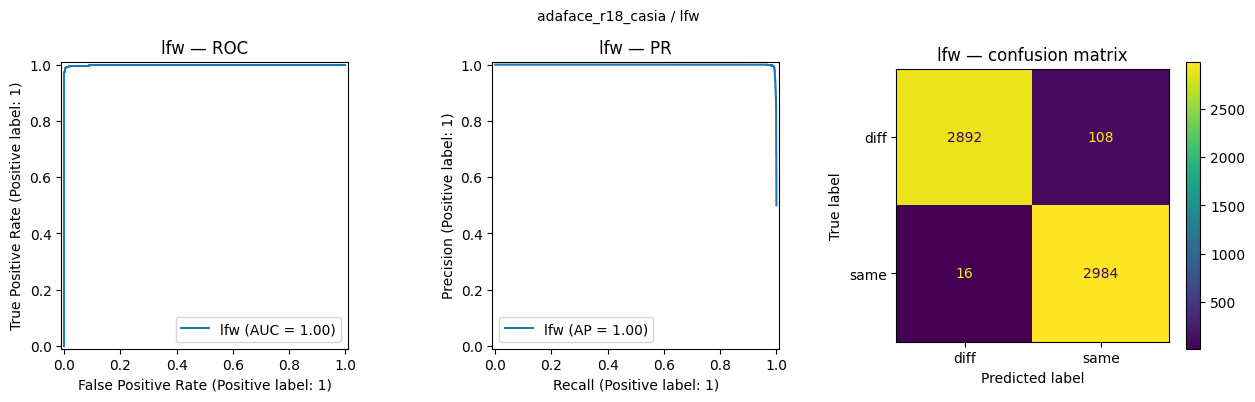


  ── cfp_fp
    AUC : 0.9590
    AP  : 0.9710
    F1  : 0.9205
    ACC : 0.9207


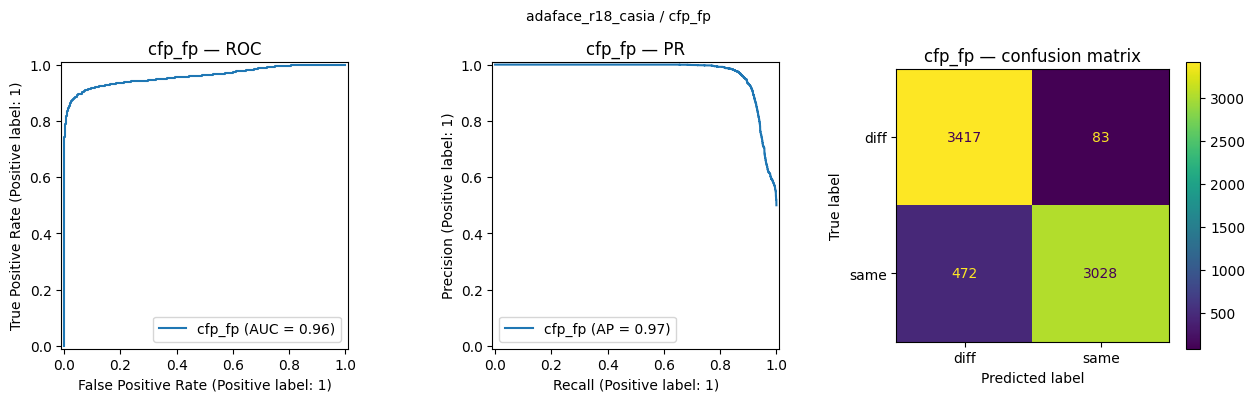


  ── agedb_30
    AUC : 0.9761
    AP  : 0.9798
    F1  : 0.9218
    ACC : 0.9218


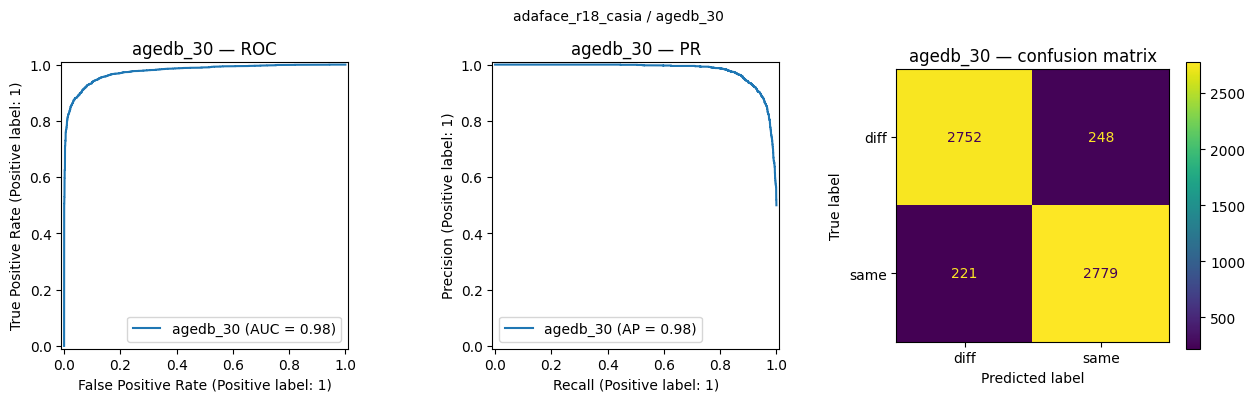


  ── sllfw
    AUC : 0.9933
    AP  : 0.9947
    F1  : 0.8171
    ACC : 0.8225


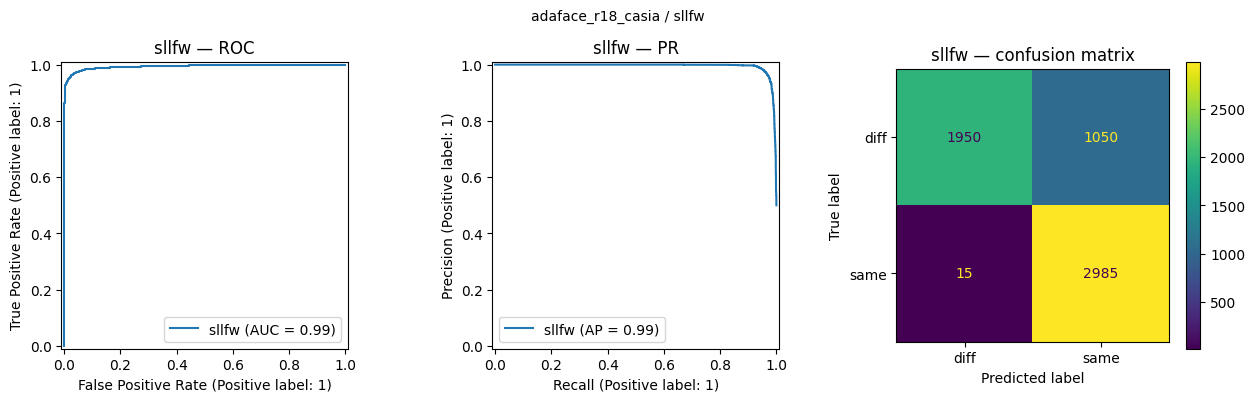


  ── talfw
    AUC : 0.4989
    AP  : 0.5044
    F1  : 0.5079
    ACC : 0.5103


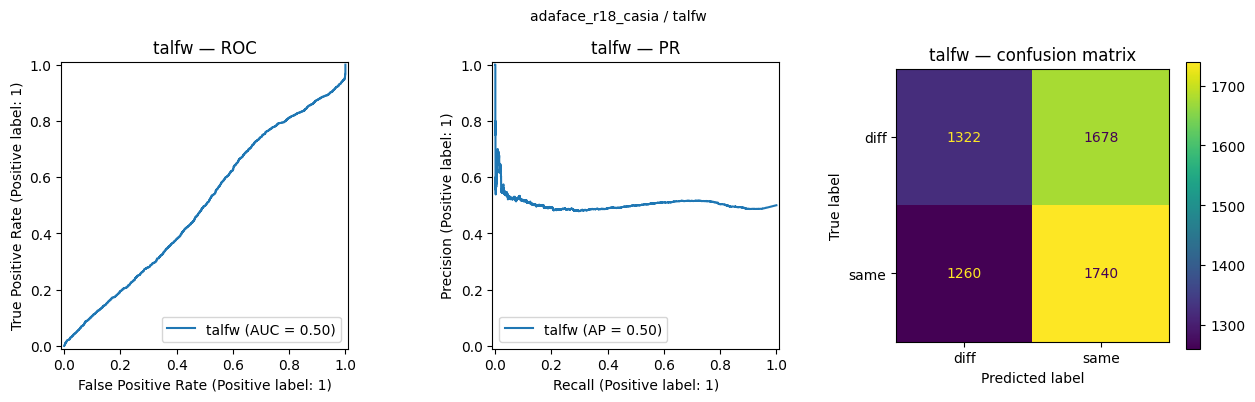


═══════════════════════════════════════════════════════
  adaface_r50_ms1mv2  (ir_50)
═══════════════════════════════════════════════════════

[1/2] Calibrating on 5000 train pairs...
  Pairs used    : 5,000  (skipped 0)
  Cal AUC       : 0.9591
  Cal threshold : 0.1512

[2/2] Evaluating benchmarks (threshold=0.1512)...

  ── lfw
    AUC : 0.9985
    AP  : 0.9991
    F1  : 0.9955
    ACC : 0.9955


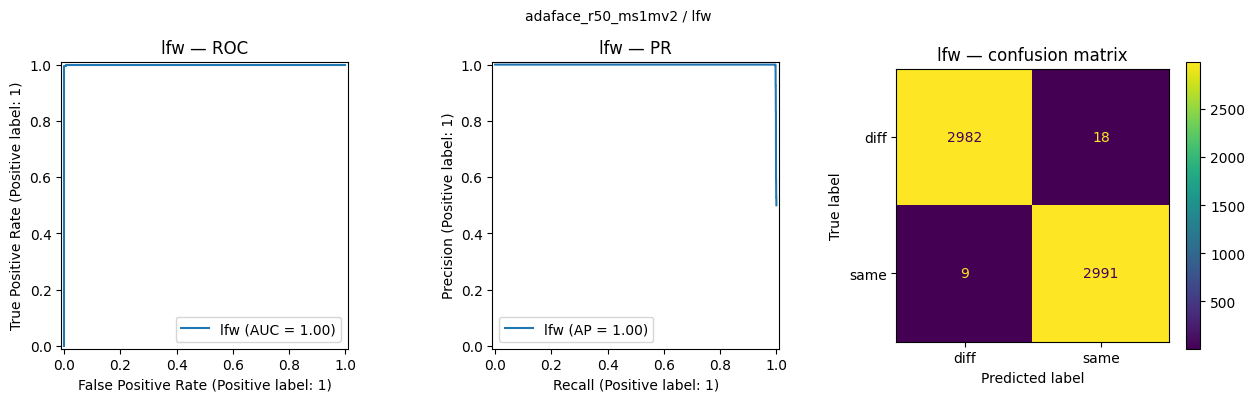


  ── cfp_fp
    AUC : 0.9775
    AP  : 0.9851
    F1  : 0.9602
    ACC : 0.9603


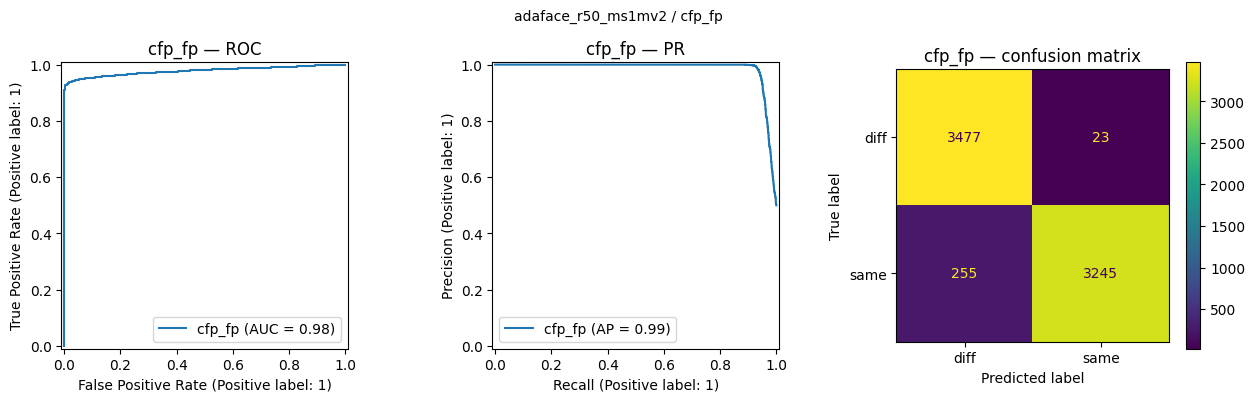


  ── agedb_30
    AUC : 0.9907
    AP  : 0.9938
    F1  : 0.9773
    ACC : 0.9773


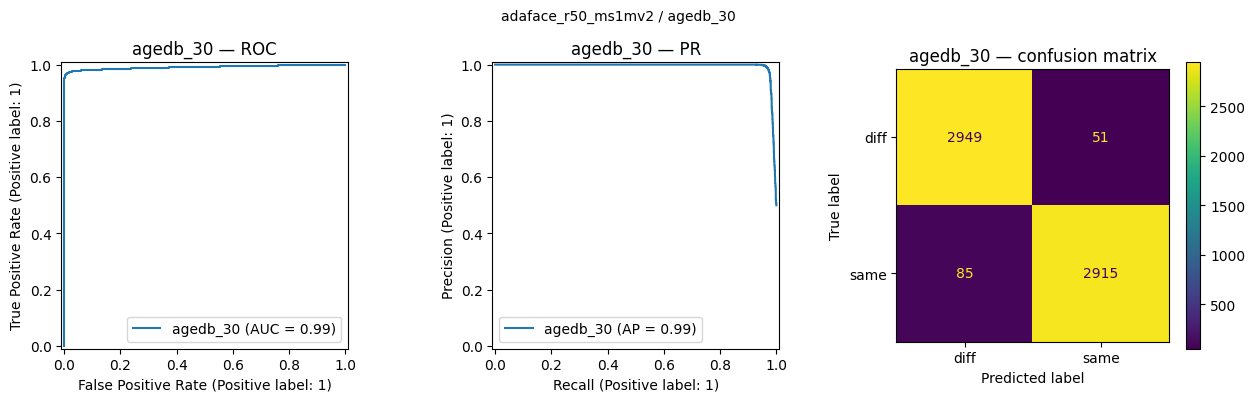


  ── sllfw
    AUC : 0.9984
    AP  : 0.9991
    F1  : 0.9511
    ACC : 0.9512


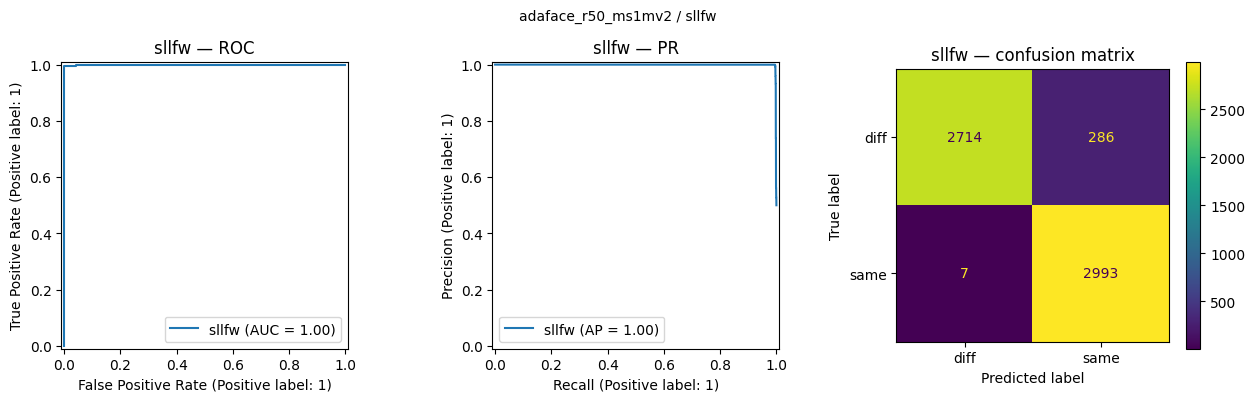


  ── talfw
    AUC : 0.7123
    AP  : 0.7181
    F1  : 0.6485
    ACC : 0.6510


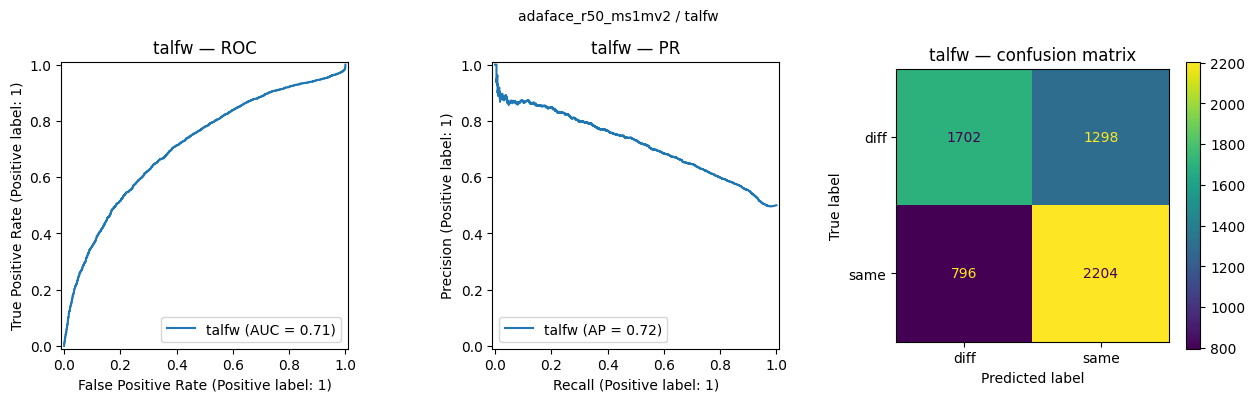

In [16]:
device      = 'cuda' if torch.cuda.is_available() else 'cpu'
all_results = []

with open(REC_PATH, 'rb') as rec_file:
    for model_name, (ckpt_path, arch) in ADAFACE_MODELS.items():
        print(f"\n{'═'*55}")
        print(f"  {model_name}  ({arch})")
        print(f"{'═'*55}")

        model     = load_adaface(ckpt_path, arch).to(device)
        model_dir = os.path.join(OUT_DIR, model_name)
        os.makedirs(model_dir, exist_ok=True)

        # ── Step 1: calibrate on train pairs ─────────────────────
        print(f"\n[1/2] Calibrating on {CAL_SAMPLE_SIZE} train pairs...")
        cal_sims, cal_labels = [], []
        skipped = 0

        for off_a, off_b, lbl in cal_pairs:
            img_a = read_img_from_offset(rec_file, off_a)
            img_b = read_img_from_offset(rec_file, off_b)
            if img_a is None or img_b is None:
                skipped += 1
                continue
            emb_a = get_embedding(model, img_a, device)
            emb_b = get_embedding(model, img_b, device)
            sim   = float(np.dot(emb_a, emb_b))   # both L2-normalized → cosine sim
            cal_sims.append(sim)
            cal_labels.append(lbl)

        cal_sims   = np.array(cal_sims)
        cal_labels = np.array(cal_labels)
        threshold  = find_optimal_threshold(cal_sims, cal_labels)

        print(f"  Pairs used    : {len(cal_sims):,}  (skipped {skipped})")
        print(f"  Cal AUC       : {roc_auc_score(cal_labels, cal_sims):.4f}")
        print(f"  Cal threshold : {threshold:.4f}")

        pd.DataFrame([{
            'model': model_name, 'threshold': threshold,
            'cal_auc': roc_auc_score(cal_labels, cal_sims),
        }]).to_csv(os.path.join(model_dir, 'calibration.csv'), index=False)

        # ── Step 2: eval on test benchmarks ──────────────────────
        print(f"\n[2/2] Evaluating benchmarks (threshold={threshold:.4f})...")

        for name, bin_path in EVAL_BINS.items():
            print(f"\n  ── {name}")
            with open(bin_path, 'rb') as f:
                bins, issame = pickle.load(f, encoding='bytes')
            labels = np.array(issame).astype(int)

            sims, valid_labels, skipped = [], [], 0
            for i in range(len(labels)):
                try:
                    if len(bins[i*2]) < VALID_MIN_BYTES or \
                       len(bins[i*2+1]) < VALID_MIN_BYTES:
                        skipped += 1
                        continue
                    img_a = Image.open(io.BytesIO(bins[i*2])).convert('RGB')
                    img_b = Image.open(io.BytesIO(bins[i*2+1])).convert('RGB')
                except Exception:
                    skipped += 1
                    continue

                emb_a = get_embedding(model, img_a, device)
                emb_b = get_embedding(model, img_b, device)
                sims.append(float(np.dot(emb_a, emb_b)))
                valid_labels.append(labels[i])

            if skipped > 0:
                print(f"    Skipped {skipped} invalid pairs")

            probs   = np.array(sims)
            labels_ = np.array(valid_labels)
            metrics = compute_metrics(probs, labels_, threshold)
            preds   = (probs >= threshold).astype(int)

            print(f"    AUC : {metrics['auc']:.4f}")
            print(f"    AP  : {metrics['ap']:.4f}")
            print(f"    F1  : {metrics['f1']:.4f}")
            print(f"    ACC : {metrics['acc']:.4f}")

            pd.DataFrame({
                'sim'      : probs,
                'label'    : labels_,
                'pred'     : preds,
                'threshold': threshold,
            }).to_csv(os.path.join(model_dir, f'{name}_predictions.csv'), index=False)

            save_plots(probs, labels_, preds, name, model_name, model_dir)
            all_results.append({'model': model_name, 'benchmark': name, **metrics})

In [17]:
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)

for metric in ['auc', 'ap', 'f1', 'acc']:
    pivot = summary_df.pivot(index='benchmark', columns='model', values=metric)
    pivot = pivot.reindex(['lfw', 'cfp_fp', 'agedb_30', 'sllfw', 'talfw'])
    print(f"\n== {metric.upper()} ===")
    print(pivot.round(4).to_string())


== AUC ===
model      adaface_r18_casia  adaface_r50_ms1mv2
benchmark                                       
lfw                   0.9990              0.9985
cfp_fp                0.9590              0.9775
agedb_30              0.9761              0.9907
sllfw                 0.9933              0.9984
talfw                 0.4989              0.7123

== AP ===
model      adaface_r18_casia  adaface_r50_ms1mv2
benchmark                                       
lfw                   0.9992              0.9991
cfp_fp                0.9710              0.9851
agedb_30              0.9798              0.9938
sllfw                 0.9947              0.9991
talfw                 0.5044              0.7181

== F1 ===
model      adaface_r18_casia  adaface_r50_ms1mv2
benchmark                                       
lfw                   0.9793              0.9955
cfp_fp                0.9205              0.9602
agedb_30              0.9218              0.9773
sllfw                 0.8171       